# 灰度图处理与图片保存

本 Notebook 系统讲解：
1. OpenCV 默认读取的 BGR 彩色图结构
2. 灰度图的读取方式与底层原理
3. 彩色图转灰度图的加权公式
4. 灰度图与彩色图在 shape、size、dtype 上的差异
5. 图像显示与保存 `cv2.imwrite()`
6. 保存时的编码参数、压缩质量与常见错误
7. 灰度化公式的深入推导与手工验证
8. Gamma 校正、线性亮度与感知亮度
9. `cv2.imread` 的更多 flags 与边界情况
10. 保存时的位深、通道匹配与格式选择
11. 图像质量评估：PSNR 与 SSIM
12. 批量处理与异常处理实践
13. 综合实践：灰度图处理流水线

# 1. 读取BGR图(默认读取)

`cv2.imread()` 默认使用 `cv2.IMREAD_COLOR` 模式，读取结果为 **3 通道 BGR** 图像。

返回的 `img` 是 `numpy.ndarray`：
- `img.shape = (h, w, c)`
- `h`：图像高度（行数）
- `w`：图像宽度（列数）
- `c`：通道数，彩色图为 3
- `dtype`：通常为 `uint8`，取值范围 0~255

注意：OpenCV 的通道顺序是 **BGR**，不是 RGB。
这意味着 `img[:, :, 0]` 是蓝色通道，`img[:, :, 2]` 是红色通道。

In [3]:
import cv2 # opencv的缩写为cv2
import matplotlib.pyplot as plt # matplotlib库用于绘图展示
import numpy as np   # numpy数值计算工具包
import os
from skimage.metrics import peak_signal_noise_ratio, structural_similarity



In [4]:
img = cv2.imread('01_Picture/01_cat.jpg') 
img.shape # (h,w,c) c表示 3 通道，这个 3 通道被 opencv 读进来是 BGR 的先后顺序的 3 通道

(414, 500, 3)

## 1.1 通道拆分观察 BGR

可以通过切片或 `cv2.split()` 查看三个通道：

```python
b, g, r = cv2.split(img)
```

或者：

```python
b = img[:, :, 0]
g = img[:, :, 1]
r = img[:, :, 2]
```

In [5]:
if img is not None:
    b, g, r = cv2.split(img)
    print('B channel shape:', b.shape)
    print('G channel shape:', g.shape)
    print('R channel shape:', r.shape)

B channel shape: (414, 500)
G channel shape: (414, 500)
R channel shape: (414, 500)


## 1.2 验证 BGR 与 RGB 的差异

将 BGR 转为 RGB 后，用 Matplotlib 显示，颜色才会正常。

```python
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
```

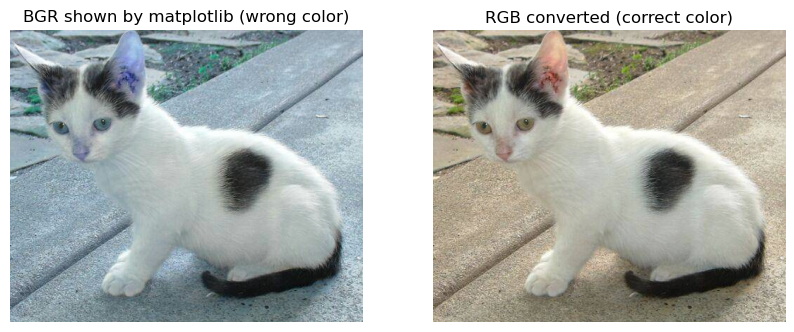

In [6]:
if img is not None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.title('BGR shown by matplotlib (wrong color)')
    plt.imshow(img)
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.title('RGB converted (correct color)')
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

# 2. 读取灰度图(设置读取)

使用 `cv2.IMREAD_GRAYSCALE` 读取时，OpenCV 会在解码阶段直接将图像转换为单通道灰度图。

灰度图的特点：
- `shape = (h, w)`，没有通道维度
- `dtype = uint8`
- 每个像素值表示亮度，0 为黑，255 为白
- 数据量约为彩色图的 1/3

灰度化并不是简单取 R、G、B 的平均值，而是使用加权公式：

```text
Gray = 0.299 * R + 0.587 * G + 0.114 * B
```

这是因为人眼对绿色最敏感、对蓝色最不敏感。

In [7]:
img_gray = cv2.imread('01_Picture/01_cat.jpg', cv2.IMREAD_GRAYSCALE)    
# img_gray = cv2.imread('01_Picture/01_cat.jpg', cv2.IMREAD_COLOR)  # BGR图  
img_gray  # 只有一个通道，同样是 uint8 类型

array([[153, 157, 162, ..., 174, 173, 172],
       [119, 124, 129, ..., 173, 172, 171],
       [120, 124, 130, ..., 172, 171, 170],
       ...,
       [187, 182, 167, ..., 202, 191, 170],
       [165, 172, 164, ..., 185, 141, 122],
       [179, 179, 146, ..., 197, 142, 141]], shape=(414, 500), dtype=uint8)

In [8]:
print('type(img_gray):', type(img_gray))
print('img_gray.size: ', img_gray.size)  # 414 × 500 = 207000
print('img_gray.dtype:', img_gray.dtype)
print('img_gray.shape:', img_gray.shape) # 只有一个通道

type(img_gray): <class 'numpy.ndarray'>
img_gray.size:  207000
img_gray.dtype: uint8
img_gray.shape: (414, 500)


## 2.1 彩色图转灰度图 `cv2.cvtColor()`

如果已经读取了 BGR 彩色图，也可以用 `cv2.cvtColor()` 转换：

```python
img_gray2 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
```

结果与 `cv2.imread(..., cv2.IMREAD_GRAYSCALE)` 基本一致。

常见颜色空间转换代码：
- `cv2.COLOR_BGR2GRAY`：BGR 转灰度
- `cv2.COLOR_BGR2RGB`：BGR 转 RGB
- `cv2.COLOR_GRAY2BGR`：灰度转 BGR（3 通道但无彩色信息）

In [9]:
if img is not None:
    img_gray2 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    print('img_gray2.shape:', img_gray2.shape)
    print('与直接读取灰度图是否接近:', np.allclose(img_gray, img_gray2, atol=1))

img_gray2.shape: (414, 500)
与直接读取灰度图是否接近: False


## 2.2 手工验证灰度化加权公式

OpenCV 的灰度化公式为：

```text
Gray = 0.299 * R + 0.587 * G + 0.114 * B
```

注意：输入是 BGR 顺序，因此计算时要先拆分通道。
由于 `uint8` 运算会溢出，建议先转为 `float32` 再计算，最后再转回 `uint8`。

In [10]:
if img is not None:
    b_f = img[:, :, 0].astype(np.float32)
    g_f = img[:, :, 1].astype(np.float32)
    r_f = img[:, :, 2].astype(np.float32)
    gray_manual = 0.299 * r_f + 0.587 * g_f + 0.114 * b_f
    gray_manual = np.clip(gray_manual, 0, 255).astype(np.uint8)
    diff = np.abs(gray_manual.astype(np.int16) - img_gray2.astype(np.int16))
    print('手工灰度化与 cv2.cvtColor 的最大差值:', diff.max())
    print('平均差值:', diff.mean())
    print('差值大于 1 的像素比例:', (diff > 1).mean())

手工灰度化与 cv2.cvtColor 的最大差值: 1
平均差值: 0.5350917874396135
差值大于 1 的像素比例: 0.0


## 2.3 简单平均法与加权平均法对比

简单平均法：

```text
Gray_avg = (R + G + B) / 3
```

加权平均法更符合人眼感知，因此 OpenCV 默认使用加权公式。
可以通过可视化对比两者的差异。

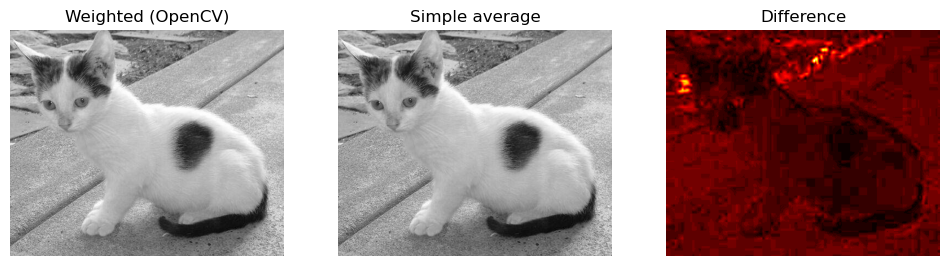

In [11]:
if img is not None:
    gray_avg = ((r_f + g_f + b_f) / 3.0)
    gray_avg = np.clip(gray_avg, 0, 255).astype(np.uint8)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title('Weighted (OpenCV)')
    plt.imshow(img_gray2, cmap='gray')
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.title('Simple average')
    plt.imshow(gray_avg, cmap='gray')
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.title('Difference')
    plt.imshow(np.abs(gray_avg.astype(np.int16) - img_gray2.astype(np.int16)), cmap='hot')
    plt.axis('off')
    plt.show()

# 3. 显示图片

OpenCV 显示机制回顾：
- `cv2.imshow(winname, img)`：创建窗口并显示图像
- `cv2.waitKey(0)`：无限等待按键，驱动 GUI 事件循环
- `cv2.destroyAllWindows()`：销毁所有窗口

注意：
- 灰度图可以直接用 `cv2.imshow()` 显示。
- 如果要用 Matplotlib 显示灰度图，应设置 `cmap='gray'`，否则会使用默认彩色映射。
- 在 Jupyter 中，OpenCV 窗口可能无法弹出，建议改用 Matplotlib 显示。

In [ ]:
def cv_show(name, img):
    """
    使用 OpenCV 显示图像。
    :param name: 窗口名称
    :param img: 图像数组
    """
    cv2.imshow(name, img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    
if img_gray is not None:
    cv_show('image_cat_gray', img_gray)

In [ ]:
# 用 Matplotlib 显示灰度图
if img_gray is not None:
    plt.imshow(img_gray, cmap='gray')
    plt.axis('off')
    plt.show()

## 3.1 灰度直方图与亮度分布

直方图可以直观展示灰度图中各亮度值的像素数量分布。

```python
plt.hist(img_gray.ravel(), bins=256, range=[0, 256])
```

In [ ]:
if img_gray is not None:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.title('Gray image')
    plt.imshow(img_gray, cmap='gray')
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.title('Histogram')
    plt.hist(img_gray.ravel(), bins=256, range=[0, 256], color='gray')
    plt.xlabel('Pixel value')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

# 4. 保存图片

## 4.1 `cv2.imwrite()` 基本用法

```python
retval = cv2.imwrite(filename, img, params)
```

参数说明：
- `filename`：保存路径，扩展名决定编码格式，如 `.jpg`、`.png`、`.bmp`、`.tif`。
- `img`：要保存的图像数组，通常为 `uint8`。
- `params`：可选编码参数。

返回值：
- `True`：保存成功
- `False`：保存失败（路径不存在、权限不足、格式不支持等）

注意：
- `cv2.imwrite()` 不会自动创建目录，目录必须已存在。
- 保存彩色图时按 BGR 顺序写入，用 OpenCV 再读取仍然正确。
- 保存灰度图时，扩展名和编码参数会影响结果。

In [ ]:
if img_gray is not None:
    ok = cv2.imwrite('01_Picture/02_cat_gray.jpg', img_gray) # 保存图片
    print('保存成功:', ok)

## 4.2 JPEG 压缩质量参数

JPEG 是有损压缩格式，可以通过 `cv2.IMWRITE_JPEG_QUALITY` 控制质量：

```python
cv2.imwrite('out.jpg', img, [cv2.IMWRITE_JPEG_QUALITY, 90])
```

- 取值范围 0~100
- 默认值 95
- 值越大，质量越高，文件越大
- 值越小，压缩越强，可能出现块状伪影

In [ ]:
if img is not None:
    cv2.imwrite('01_Picture/02_cat_q90.jpg', img, [cv2.IMWRITE_JPEG_QUALITY, 90])
    cv2.imwrite('01_Picture/02_cat_q50.jpg', img, [cv2.IMWRITE_JPEG_QUALITY, 50])
    print('JPEG 质量对比图已保存')

## 4.3 PNG 压缩级别

PNG 是无损压缩格式，可以通过 `cv2.IMWRITE_PNG_COMPRESSION` 控制压缩级别：

```python
cv2.imwrite('out.png', img, [cv2.IMWRITE_PNG_COMPRESSION, 3])
```

- 取值范围 0~9
- 0 表示不压缩，9 表示最大压缩
- 压缩级别越高，文件越小，但保存越慢
- 无损，不会损失图像质量

In [ ]:
if img is not None:
    cv2.imwrite('01_Picture/02_cat.png', img, [cv2.IMWRITE_PNG_COMPRESSION, 3])
    print('PNG 图像已保存')

## 4.4 保存时的位深与通道匹配

`cv2.imwrite()` 对图像数组有一定要求：

- 常见支持 `uint8`，部分格式支持 `uint16`、`float32`（如 TIFF、PNG）。
- 彩色图应为 3 通道，灰度图应为 1 通道或 2 维数组。
- 如果 dtype 不是 `uint8`，保存结果可能异常或失败。

推荐做法：

```python
if img.dtype != np.uint8:
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
```

In [ ]:
if img is not None:
    img_float = img.astype(np.float32) / 255.0
    ok_float = cv2.imwrite('01_Picture/02_cat_float.jpg', img_float)
    print('直接保存 float32 是否成功:', ok_float)
    img_uint8 = (img_float * 255).astype(np.uint8)
    ok_uint8 = cv2.imwrite('01_Picture/02_cat_uint8.jpg', img_uint8)
    print('转换为 uint8 后保存是否成功:', ok_uint8)

## 4.5 不同格式文件大小对比

同一张图保存为 JPEG、PNG、BMP 时，文件大小差异明显。

可以通过 `os.path.getsize()` 获取文件大小。

In [ ]:
if img is not None:
    paths = {
        'JPEG Q90': '01_Picture/02_cat_q90.jpg',
        'JPEG Q50': '01_Picture/02_cat_q50.jpg',
        'PNG': '01_Picture/02_cat.png',
        'BMP': '01_Picture/02_cat.bmp'
    }
    cv2.imwrite(paths['BMP'], img)
    for name, p in paths.items():
        if os.path.exists(p):
            print(f'{name}: {os.path.getsize(p) / 1024:.1f} KB')
        else:
            print(f'{name}: 文件不存在')

# 5. 灰度图与彩色图的对比总结

| 项目 | 彩色图 BGR | 灰度图 Gray |
|------|------------|-------------|
| shape | (h, w, 3) | (h, w) |
| 通道数 | 3 | 1 |
| dtype | uint8 | uint8 |
| 数据量 | h×w×3 | h×w |
| 颜色信息 | 有 | 无 |
| 常见用途 | 显示、颜色分析 | 边缘检测、阈值、特征提取 |

# 6. 常见问题与注意事项

1. **保存失败返回 False**：目录不存在、路径含中文、权限不足、扩展名不支持。
2. **灰度图被保存成彩色**：用 `.jpg` 保存灰度图时，某些解码器可能仍按 3 通道处理，建议用 `.png`。
3. **JPEG 有损压缩**：反复保存 JPEG 会累积失真。
4. **PNG 无损但文件大**：适合保存灰度图、掩膜、二值图。
5. **中文路径问题**：OpenCV 对中文路径支持不稳定，可用 `cv2.imencode()` + `tofile()` 保存。
6. **dtype 不是 uint8**：`cv2.imwrite()` 可能保存失败或结果异常。
7. **Jupyter 中窗口不显示**：无 GUI 环境或后端冲突，建议改用 Matplotlib。

## 6.1 中文路径保存方案

如果路径包含中文，可以使用：

```python
cv2.imencode('.jpg', img)[1].tofile('中文路径.jpg')
```

读取时对应使用：

```python
img = cv2.imdecode(np.fromfile('中文路径.jpg', dtype=np.uint8), cv2.IMREAD_COLOR)
```

In [ ]:
# 中文路径保存示例
if img is not None:
    cv2.imencode('.jpg', img)[1].tofile('01_Picture/中文_猫.jpg')
    print('中文路径保存成功')

# 7. Gamma 校正与感知亮度

人眼对亮度的感知是非线性的，通常近似为幂函数关系：

```text
V_out = A * V_in ^ gamma
```

- `gamma < 1`：提亮暗部
- `gamma > 1`：压暗亮部

OpenCV 提供 `cv2.LUT()` 进行快速查表变换。

In [ ]:
if img_gray is not None:
    gamma = 0.5
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype(np.uint8)
    img_gamma = cv2.LUT(img_gray, table)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title('Original gray')
    plt.imshow(img_gray, cmap='gray')
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.title(f'Gamma = {gamma}')
    plt.imshow(img_gamma, cmap='gray')
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.title('LUT curve')
    plt.plot(table)
    plt.xlabel('Input')
    plt.ylabel('Output')
    plt.tight_layout()
    plt.show()

# 8. `cv2.imread` 的更多 flags 与边界情况

常用 flags：

| flag | 值 | 含义 |
|------|----|------|
| `cv2.IMREAD_COLOR` | 1 | 默认，BGR 三通道 |
| `cv2.IMREAD_GRAYSCALE` | 0 | 灰度单通道 |
| `cv2.IMREAD_UNCHANGED` | -1 | 保留原始通道，包括 alpha |
| `cv2.IMREAD_ANYDEPTH` | 2 | 保留 16/32 位深度 |
| `cv2.IMREAD_ANYCOLOR` | 4 | 任意颜色格式 |
| `cv2.IMREAD_REDUCED_GRAYSCALE_2` | 16 | 灰度并缩小 1/2 |

边界情况：
- 文件不存在：返回 `None`，不会抛异常。
- 路径含中文：可能读取失败，需用 `np.fromfile` + `cv2.imdecode`。
- 损坏文件：可能返回 `None` 或部分解码。

In [ ]:
# 演示读取不存在文件
img_none = cv2.imread('01_Picture/not_exist.jpg')
print('读取不存在文件返回:', img_none)

# 演示 IMREAD_UNCHANGED 读取 PNG alpha
if img is not None:
    cv2.imwrite('01_Picture/02_cat_alpha.png', img)
    img_unchanged = cv2.imread('01_Picture/02_cat_alpha.png', cv2.IMREAD_UNCHANGED)
    print('IMREAD_UNCHANGED shape:', None if img_unchanged is None else img_unchanged.shape)
    img_color = cv2.imread('01_Picture/02_cat_alpha.png', cv2.IMREAD_COLOR)
    print('IMREAD_COLOR shape:', None if img_color is None else img_color.shape)

# 9. 图像质量评估：PSNR 与 SSIM

保存 JPEG 会引入有损压缩，可以用以下指标评估失真程度：

- **PSNR**（峰值信噪比）：值越大越好，通常 > 30 dB 表示质量较好。
- **SSIM**（结构相似性）：取值 0~1，越接近 1 越相似。

```python
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
```

In [ ]:
if img is not None:
    img_q90 = cv2.imread('01_Picture/02_cat_q90.jpg')
    img_q50 = cv2.imread('01_Picture/02_cat_q50.jpg')
    if img_q90 is not None and img_q50 is not None:
        psnr_q90 = peak_signal_noise_ratio(img, img_q90, data_range=255)
        psnr_q50 = peak_signal_noise_ratio(img, img_q50, data_range=255)
        ssim_q90 = structural_similarity(img, img_q90, channel_axis=2, data_range=255)
        ssim_q50 = structural_similarity(img, img_q50, channel_axis=2, data_range=255)
        print(f'JPEG Q90 -> PSNR: {psnr_q90:.2f} dB, SSIM: {ssim_q90:.4f}')
        print(f'JPEG Q50 -> PSNR: {psnr_q50:.2f} dB, SSIM: {ssim_q50:.4f}')

# 10. 批量处理与异常处理实践

实际项目中经常需要批量读取、灰度化并保存图片。

建议：
- 使用 `os.listdir()` 或 `glob` 遍历文件。
- 用 `try/except` 捕获异常。
- 检查 `cv2.imread()` 返回值是否为 `None`。
- 保存前确保输出目录存在。

In [ ]:
def batch_gray(input_dir, output_dir, exts=('.jpg', '.jpeg', '.png', '.bmp')):
    """
    批量将输入目录中的图片转为灰度图并保存到输出目录。
    :param input_dir: 输入目录
    :param output_dir: 输出目录
    :param exts: 支持的文件扩展名
    """
    os.makedirs(output_dir, exist_ok=True)
    count = 0
    for fname in os.listdir(input_dir):
        if not fname.lower().endswith(exts):
            continue
        in_path = os.path.join(input_dir, fname)
        out_path = os.path.join(output_dir, os.path.splitext(fname)[0] + '_gray.png')
        try:
            im = cv2.imread(in_path, cv2.IMREAD_GRAYSCALE)
            if im is None:
                print(f'跳过无法读取的文件: {fname}')
                continue
            ok = cv2.imwrite(out_path, im)
            if ok:
                count += 1
            else:
                print(f'保存失败: {out_path}')
        except Exception as e:
            print(f'处理 {fname} 时出错: {e}')
    print(f'共处理 {count} 张图片，输出目录: {output_dir}')

batch_gray('01_Picture', '01_Picture/gray_output')

# 11. 综合实践：灰度图处理流水线

下面把读取、灰度化、Gamma 校正、直方图均衡化、保存整合为一个流水线。

步骤：
1. 读取彩色图。
2. 转为灰度图。
3. 应用 Gamma 校正。
4. 应用直方图均衡化。
5. 保存结果并对比。

In [ ]:
def gray_pipeline(path, out_dir='01_Picture/pipeline_output'):
    """
    灰度图处理流水线。
    :param path: 输入图片路径
    :param out_dir: 输出目录
    :return: 处理结果字典
    """
    os.makedirs(out_dir, exist_ok=True)
    bgr = cv2.imread(path)
    if bgr is None:
        raise FileNotFoundError(f'无法读取图片: {path}')
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    gamma = 0.8
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype(np.uint8)
    gray_gamma = cv2.LUT(gray, table)
    gray_eq = cv2.equalizeHist(gray_gamma)
    cv2.imwrite(os.path.join(out_dir, '01_gray.png'), gray)
    cv2.imwrite(os.path.join(out_dir, '02_gamma.png'), gray_gamma)
    cv2.imwrite(os.path.join(out_dir, '03_equalized.png'), gray_eq)
    return {'gray': gray, 'gamma': gray_gamma, 'equalized': gray_eq}

if img is not None:
    result = gray_pipeline('01_Picture/01_cat.jpg')
    plt.figure(figsize=(15, 4))
    for i, (name, im) in enumerate(result.items(), 1):
        plt.subplot(1, 3, i)
        plt.title(name)
        plt.imshow(im, cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# 12. 小结

- `cv2.imread()` 默认读取 BGR 彩色图，使用 `cv2.IMREAD_GRAYSCALE` 可读取灰度图。
- 灰度图只有两个维度 `(h, w)`，每个像素表示亮度。
- 灰度化使用加权公式：`0.299R + 0.587G + 0.114B`。
- `cv2.imwrite()` 返回布尔值，保存格式由扩展名决定。
- JPEG 用 `IMWRITE_JPEG_QUALITY` 控制质量，PNG 用 `IMWRITE_PNG_COMPRESSION` 控制压缩级别。
- 中文路径建议使用 `imencode` + `tofile` 方案。
- Gamma 校正可调整感知亮度，直方图均衡化可增强对比度。
- PSNR 和 SSIM 可用于评估有损压缩后的图像质量。
- 批量处理时要注意目录创建、文件存在性和异常捕获。